In [1]:
# import os; os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.2' # NOTE: jax preallocates GPU (default 75%)


import jax.numpy as jnp
import numpy as np
from numba import vectorize, njit, prange, jit
import jax.scipy.special as jsp
import numba
import math
from jax import jit

from jax import vmap
import matplotlib.pyplot as plt
import pandas as pd
import jax
from scipy.interpolate import CubicSpline as CS
from functools import partial
import jax.random as jrandom


In [2]:
import HOD_NRV
halo = pd.read_parquet('/Users/ler13nrv/Documents/halo_catalogue.parquet')

In [3]:
b = np.column_stack([halo.b_x,halo.b_y,halo.b_z])
a = np.column_stack([halo.a_x,halo.a_y,halo.a_z])
b = b/np.linalg.norm(b,axis=1)[:,None]
a = a/np.linalg.norm(a,axis=1)[:,None]
c = np.cross(b,a)

In [4]:
cosmo_params = {'flat': True, 'H0': 67.74, 'Om0': 0.3089, 'Ob0': 0.0486, 'sigma8': 0.8159, 'ns': 0.9667}
HOD_model =HOD_NRV.HOD_models.Occupation("ELG_GHOD",cosmo_params,z_snap=1.03)
Ac = 1.
Mmin = 12.
sig_M = 0.6
M1 = 13.
As = 1.
alpha = 0.6
kappa = 0.8
logM = jnp.geomspace(10.6,15,1000)
dict_params = {'kappa':kappa,'Ac':Ac,'As':As,'Mmin':Mmin, 'sig_M':sig_M,'M1':M1,'alpha':alpha}
HOD_model.set_params(dict_params)



In [5]:
Rvir = jnp.array(halo.rvir[0:20000].values)
Rs = jnp.array(halo.rs_klypin[0:20000].values)
Ns = jnp.array(np.random.randint(1,10,20000))
c = Rvir/Rs
centers = jnp.stack([halo.x.values,halo.y.values,halo.z.values],axis=1)[0:20000]
velocities = jnp.stack([halo.vx.values,halo.vy.values,halo.vz.values],axis=1)[0:20000]
vrms = halo.vrms.values[0:1000]
N = int(jnp.sum(Ns))

In [138]:
key = jrandom.PRNGKey(0)
key, key_r,key_theta,key_phi = jrandom.split(key,num=4)

In [6]:

import jax.scipy.interpolate as jinterp
# interpolate = RegularGridInterpolator(points, values, method='linear')

    
@jit
def NFW_CDF(r,rs,c):
    CDF = (jnp.log(1+r/rs) - (r/rs)/(1+r/rs))/(jnp.log(1+c) - c/(1+c))
    return CDF

@partial(jit,static_argnames='num_point')
def inverse_CDF(c,rs,Rvir,key,num_point):
    r  = jnp.logspace(-2,jnp.log10(Rvir),num_point)
    key,subkey = jrandom.split(key)
    CDF = NFW_CDF(r,rs,c)
    uniform_random = jrandom.uniform(subkey, shape=(num_point,))
    inverse_cdf = jnp.interp(uniform_random, CDF, r)
    return inverse_cdf

@partial(jit,static_argnames='num_point')
def nfw_inv_cdf_sampler(u, Rs, Rvir, key, num_point):
    r_vals = jnp.linspace(1e-3, Rvir, 1000)
    x = r_vals / Rs
    m_vals = jnp.log(1 + x) - x / (1 + x)
    CDF = m_vals / m_vals[-1]
    r_samples = jnp.interp(u,CDF, r_vals)
    return r_samples

In [154]:
@partial(jit,static_argnames='n')
def random_uniform_jax(key,n,a=0,b=1):
    key, subkey = jrandom.split(key)
    result = jrandom.uniform(subkey, (n,),minval=a,maxval=b)
    return result

In [ ]:
@partial(jit,static_argnames=["N"])
def single_halo(r_grid,Rvir, Rs, N):
    key = jrandom.key(np.random.randint(0,int(2**32)))
    x = r_grid / Rs
    m_vals = jnp.log(1 + x) - x / (1 + x)
    CDF = m_vals / m_vals[-1]
    u = random_uniform_jax(key,N)
    r_samples = jnp.interp(u,CDF, r_grid)
    return r_samples


#@partial(jit, static_argnames=["num_points"])
def batched_inverse_cdf(Rvir_array, Rs_array,N, num_points=1024):
    r_grid = jnp.logspace(-3, jnp.log10(Rvir_array), num_points)
    return vmap(single_halo)(r_grid,Rvir_array, Rs_array,N)

In [158]:
N = jnp.array(np.random.randint(1,100,size=len(Rvir)))
result=batched_inverse_cdf(Rvir,Rs,Ns)

TypeError: Shapes must be 1D sequences of concrete values of integer type, got (Traced<ShapedArray(int32[])>with<BatchTrace(level=1/0)> with
  val = Array([1, 2, 9, ..., 2, 2, 5], dtype=int32)
  batch_dim = 0,).
If using `jit`, try using `static_argnums` or applying `jit` to smaller subfunctions.
This BatchTracer with object id 15281880416 was created on line:
  /var/folders/qr/tbts9_sd3r1_967wkscjt3t80000gn/T/ipykernel_2502/1996944076.py:16 (batched_inverse_cdf)

In [125]:
Ns

Array([1, 2, 9, ..., 2, 2, 5], dtype=int32)

In [ ]:
@partial(jit, static_argnames=['grid_size', 'cdf_points'])
def create_nfw_emulator(grid_size=60, cdf_points=2000):
    """
    Create an emulator for NFW profiles based on a grid of parameters
    
    Args:
        grid_size: Number of grid points for each parameter
        cdf_points: Number of points to use for the CDF evaluation
        
    Returns:
        Interpolator function that can quickly evaluate inverse CDF
    """
    # Create parameter grids
    u_grid = jnp.linspace(0.001, 0.999, 200)  # Uniform random values
    c_grid = jnp.geomspace(1, 30, grid_size)        # Concentration values from 1 to ~31.6
    Rvir_grid = jnp.geomspace(0.05,4, grid_size)      # Virial radii from 0.1 to 100
    # Create meshgrid for all parameter combinations
    u_mesh, c_mesh, Rvir_mesh = jnp.meshgrid(u_grid, c_grid, Rvir_grid, indexing='ij')
    
    # Compute rs from concentration and Rvir
    rs_mesh = Rvir_mesh / c_mesh
    
    # Compute r values (result of inverse CDF) for each parameter combination
    # We need to compute the CDF at many radii and then interpolate
    def compute_single_inverse_cdf(c, rs, Rvir, u):
        r_values = jnp.geomspace(0.001, Rvir, cdf_points)
        cdf_values = NFW_CDF(r_values, rs, c)
        return jnp.interp(u, cdf_values, r_values)
    
    # Use vmap to vectorize over all parameter combinations
    compute_batch = jax.vmap(jax.vmap(jax.vmap(compute_single_inverse_cdf)))
    r_values = compute_batch(c_mesh, rs_mesh, Rvir_mesh, u_mesh)
    
    return r_values

In [98]:
c_grid = jnp.geomspace(1, 30, 60)        # Concentration values from 1 to ~31.6
Rvir_grid = jnp.geomspace(0.05,4, 60) 
r_grid = jnp.logspace(-3, jnp.log10(Rvir_grid.max()), 10000)
rs_grid = Rvir_grid/c_grid


In [105]:
rs_grid

Array([0.05000001, 0.05083816, 0.05169038, 0.05255687, 0.05343788,
       0.05433368, 0.05524449, 0.05617055, 0.05711216, 0.05806953,
       0.05904297, 0.06003272, 0.06103905, 0.06206226, 0.06310261,
       0.06416042, 0.06523595, 0.06632951, 0.06744142, 0.06857193,
       0.06972142, 0.07089017, 0.07207852, 0.07328678, 0.07451531,
       0.07576443, 0.07703447, 0.07832581, 0.07963881, 0.0809738 ,
       0.08233117, 0.08371132, 0.08511457, 0.08654135, 0.08799206,
       0.0894671 , 0.09096685, 0.09249175, 0.09404219, 0.09561864,
       0.09722152, 0.09885125, 0.10050834, 0.10219317, 0.10390624,
       0.10564803, 0.10741902, 0.10921974, 0.1110506 , 0.11291214,
       0.11480491, 0.11672939, 0.11868618, 0.12067573, 0.12269863,
       0.12475544, 0.12684673, 0.12897313, 0.13113509, 0.13333334],      dtype=float32)

In [92]:
result=create_nfw_emulator()

Traced<ShapedArray(float32[60])>with<DynamicJaxprTrace(level=1/0)> Traced<ShapedArray(float32[60])>with<DynamicJaxprTrace(level=1/0)>


In [103]:
elements = result[:, 40, 40]
profile = r_grid/rs_grid[40]/((1+r_grid/rs_grid[40])**2)

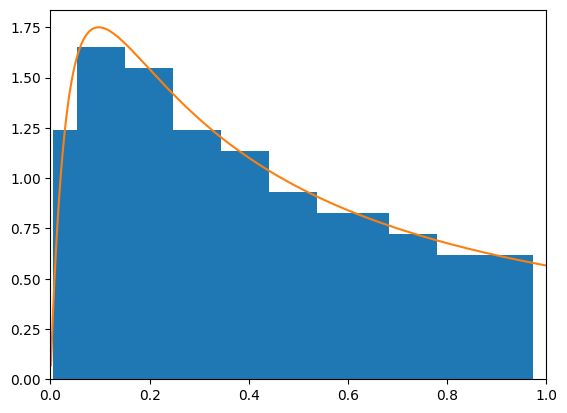

In [114]:
plt.xlim(0,1)
plt.hist(elements,bins=20,density=True)
plt.plot(r_grid,7*profile)

NameError: name 'u_grid' is not defined

In [ ]:
result

Array([[1.7404945e+00, 2.5146329e+00, 3.1317594e+00, ..., 9.7927344e+02,
        9.8219702e+02, 9.8512061e+02],
       [1.2537267e+00, 1.8140638e+00, 2.2618120e+00, ..., 9.7824670e+02,
        9.8151239e+02, 9.8477814e+02],
       [1.0808260e+00, 1.5648559e+00, 1.9520768e+00, ..., 9.7777753e+02,
        9.8119958e+02, 9.8462164e+02],
       ...,
       [9.6271938e-01, 1.3945169e+00, 1.7402748e+00, ..., 9.7741046e+02,
        9.8095483e+02, 9.8449921e+02],
       [9.1544706e-01, 1.3263272e+00, 1.6554124e+00, ..., 9.7725079e+02,
        9.8084839e+02, 9.8444598e+02],
       [1.3071954e+00, 1.8910643e+00, 2.3574970e+00, ..., 9.7837775e+02,
        9.8159979e+02, 9.8482184e+02]], dtype=float32)

In [ ]:
    u_grid = jnp.linspace(0.001, 0.999, 1000)  # Uniform random values
    c_grid = jnp.logspace(0, 1.5, 1000)        # Concentration values from 1 to ~31.6
    Rvir_grid = jnp.logspace(-2, 2, 1000)      # Virial radii from 0.1 to 100
    
    # Create meshgrid for all parameter combinations
    u_mesh, c_mesh, Rvir_mesh = jnp.meshgrid(u_grid, c_grid, Rvir_grid, indexing='ij')

In [ ]:
def generate_inverse_cdf_data(num_points=1024, num_u=512):
    r_grid = jnp.logspace(-2, jnp.log10(2.0), num_points)
    u_grid = jnp.linspace(0.001, 0.999, num_u)
    samples = []

    Rvir_vals = jnp.linspace(0.1, 2.0, 20)
    c_vals = jnp.linspace(3.0, 20.0, 20)

    for Rvir in Rvir_vals:
        for c in c_vals:
            Rs = Rvir / c
            CDF = NFW_CDF(r_grid, Rs, c)
            r_samples = jnp.interp(u_grid, CDF, r_grid)
            for i in range(num_u):
                samples.append([u_grid[i], Rvir, c, r_samples[i]])
    return jnp.array(samples)

In [ ]:
    r_grid = jnp.logspace(-2, jnp.log10(2.0), num_points)
    u_grid = jnp.linspace(0.001, 0.999, num_u)
    samples = []

    Rvir_vals = jnp.linspace(0.1, 2.0, 20)
    c_vals = jnp.linspace(3.0, 20.0, 20)

In [ ]:
r_grid = jnp.logspace(-3, jnp.log10(4.0), 512)
u_grid = jnp.linspace(1e-4, 1, 1024)
samples = []

Rvir_vals = jnp.linspace(1e-2, 2.0, 128)
c_vals = jnp.linspace(1.0, 20.0, 128)

In [ ]:
%%time
result=batched_inverse_cdf(Rvir,Rs,key)

CPU times: user 3.19 s, sys: 316 ms, total: 3.5 s
Wall time: 790 ms


In [102]:
r = np.geomspace(1e-2,Rvir[0],10000)

def NFW_PDF(x):
    """ 
    Universal NFW PDF profile as a function of x = r/rs
    """
    return  x/((1 + x)**2)

profile = r/Rs[0]/((1+r/Rs[0])**2)

In [ ]:
profile

Array([0.00045639, 0.00045685, 0.0004573 , ..., 0.08569068, 0.08562157,
       0.08555249], dtype=float32)

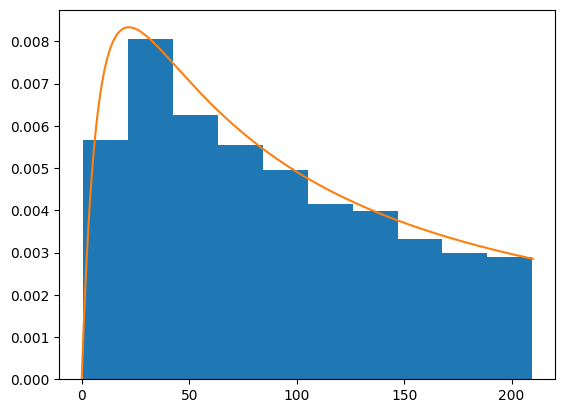

In [ ]:

plt.hist(result[0],density=True)
plt.plot(r,profile/30)

In [ ]:
%%time
result = jax.vmap(inverse_CDF,in_axes=(0,0,0,None,None))(c,Rs,Rvir,key,10000)

CPU times: user 9.97 s, sys: 4.2 s, total: 14.2 s
Wall time: 3.66 s


In [ ]:
%%time

r  = jnp.logspace(-2,jnp.log10(Rvir[0]),1000)
CDF = NFW_CDF(r,Rs[0],Rvir[0])
uniform_random = jrandom.uniform(key, shape=(10000,))
inverse_cdf = jnp.interp(uniform_random, CDF, r)



CPU times: user 4.03 ms, sys: 5.04 ms, total: 9.07 ms
Wall time: 3.18 ms
